# RecruitAI — Notebook 2: Model Training and Evaluation

This notebook encodes all cleaned resumes using **BERT sentence embeddings** (`all-MiniLM-L6-v2`), evaluates retrieval quality via **Precision@5**, and saves all model artifacts for the FastAPI backend.

**Input:** `data/resume_dataset_cleaned.csv` (from Notebook 1)  
**Outputs:**
- `../backend/models/saved/resume_embeddings.pkl`
- `../backend/models/saved/resume_data.pkl`
- `../backend/models/saved/bert_model/`

---

## Cell 1 — Imports

In [2]:
! pip install sentence_transformers

  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/588.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/588.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/588.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/588.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/588.9 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/588.9 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/588.9 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/588.9 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/588.9 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/588.9 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/588.9 kB ? eta -:--:--
   --------------------------------- ---- 524.3/588.9 kB 216.3

In [4]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
from tqdm.auto import tqdm

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': '#0A0F1E',
    'axes.facecolor':   '#111827',
    'axes.edgecolor':   '#1F2937',
    'axes.labelcolor':  '#9CA3AF',
    'xtick.color':      '#6B7280',
    'ytick.color':      '#6B7280',
    'text.color':       '#F9FAFB',
    'grid.color':       '#1F2937',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

SAVED_DIR = '../backend/models/saved'
os.makedirs(SAVED_DIR, exist_ok=True)

print('✓ Imports complete')
print(f'  Model save directory: {os.path.abspath(SAVED_DIR)}')

✓ Imports complete
  Model save directory: c:\Users\shahz\Downloads\Resume Project\recruitai\backend\models\saved


## Cell 2 — Load Cleaned Dataset

Load the preprocessed CSV generated by Notebook 1.

In [5]:
DATA_PATH = 'data/resume_dataset_cleaned.csv'

assert os.path.exists(DATA_PATH), (
    f"Cleaned dataset not found at {DATA_PATH}.\n"
    "Run 01_EDA_and_Preprocessing.ipynb first."
)

df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} cleaned resumes')
print(f'Categories: {df["Category"].nunique()}')
print(f'Columns: {list(df.columns)}')

# Ensure Resume_str column exists
assert 'Resume_str' in df.columns, "Expected 'Resume_str' column — re-run Notebook 1."

df.head(3)

Loaded 2,483 cleaned resumes
Categories: 24
Columns: ['Category', 'Resume_str']


,Category,Resume_str
0,HR,hr administrator marketing associate hr admini...
1,HR,hr specialist us hr operations summary versati...
2,HR,hr director summary 20 years experience recrui...


## Cell 3 — Encode All Resumes with BERT

`all-MiniLM-L6-v2` is a distilled BERT model producing **384-dimensional** sentence embeddings. It balances quality and speed — suitable for both CPU and GPU inference.

All resumes are encoded in a single batch with a progress bar. This is done **once** offline; the backend loads the saved matrix at startup.

In [6]:
MODEL_NAME = 'all-MiniLM-L6-v2'

print(f'Loading sentence-transformer model: {MODEL_NAME}')
model = SentenceTransformer(MODEL_NAME)
print(f'  Embedding dim : {model.get_sentence_embedding_dimension()}')
print(f'  Max seq length: {model.max_seq_length}')

resume_texts = df['Resume_str'].tolist()

print(f'\nEncoding {len(resume_texts):,} resumes (this may take a few minutes on CPU)…')
t0 = time.time()

embeddings = model.encode(
    resume_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,   # pre-normalise → cosine = dot product
)

elapsed = time.time() - t0
print(f'\n✓ Encoding complete in {elapsed:.1f}s  ({elapsed/len(resume_texts)*1000:.1f} ms/resume)')
print(f'  Embeddings shape: {embeddings.shape}  dtype: {embeddings.dtype}')

Loading sentence-transformer model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1638.37it/s]


  Embedding dim : 384
  Max seq length: 256

Encoding 2,483 resumes (this may take a few minutes on CPU)…


Batches: 100%|██████████| 39/39 [04:08<00:00,  6.38s/it]


✓ Encoding complete in 249.0s  (100.3 ms/resume)
  Embeddings shape: (2483, 384)  dtype: float32


## Cell 4 — Store Embeddings as NumPy Array

The embedding matrix shape is `(N, 384)` where N = number of resumes. We cast to `float32` to halve memory usage.

In [7]:
embeddings = embeddings.astype(np.float32)

memory_mb = embeddings.nbytes / (1024**2)
print(f'Embedding matrix: {embeddings.shape}')
print(f'Memory footprint: {memory_mb:.2f} MB')

# Quick sanity check: cosine sim of identical vector should be 1.0
sim = cosine_similarity([embeddings[0]], [embeddings[0]])[0][0]
assert abs(sim - 1.0) < 1e-4, 'Self-similarity check failed'
print('✓ Self-similarity sanity check passed')

Embedding matrix: (2483, 384)
Memory footprint: 3.64 MB
✓ Self-similarity sanity check passed


## Cell 5 — Define match_resume() Function

This is the core retrieval function used by the backend. We replicate it here for interactive testing.

In [8]:
def match_resume(job_description: str, top_k: int = 5) -> pd.DataFrame:
    """
    Embed the JD and return the top-k most similar resumes.
    
    Returns a DataFrame with columns:
        rank, score (%), category, snippet (first 200 chars)
    """
    jd_vec = model.encode([job_description], normalize_embeddings=True)[0]
    scores = cosine_similarity([jd_vec], embeddings)[0]   # shape (N,)
    top_idx = np.argsort(scores)[::-1][:top_k]

    rows = []
    for rank, idx in enumerate(top_idx, start=1):
        rows.append({
            'rank':     rank,
            'score':    round(float(scores[idx]) * 100, 2),
            'category': df.iloc[idx]['Category'],
            'snippet':  df.iloc[idx]['Resume_str'][:200] + '…',
        })

    return pd.DataFrame(rows)


print('✓ match_resume() defined')

✓ match_resume() defined


## Cell 6 — Demo: Test with 3 Sample Job Descriptions

Each JD targets a different field. We expect top results to come from the matching category.

In [9]:
sample_jds = [
    (
        "Data Science",
        "We are looking for a Senior Data Scientist with expertise in Python, machine learning, "
        "deep learning, PyTorch, TensorFlow, and statistical modelling. Experience with NLP and "
        "large language models is a strong plus."
    ),
    (
        "Java Developer",
        "Seeking an experienced Java backend developer with 5+ years of experience in Spring Boot, "
        "microservices architecture, REST APIs, SQL databases, and CI/CD pipelines."
    ),
    (
        "HR Manager",
        "HR Manager role requiring expertise in talent acquisition, employee relations, performance "
        "management, HRIS systems, and employment law compliance."
    ),
]

for label, jd in sample_jds:
    print(f'\n{'='*60}')
    print(f'JD: [{label}]')
    print(f'Query: "{jd[:80]}…"')
    results = match_resume(jd, top_k=5)
    print(results.to_string(index=False))


JD: [Data Science]
Query: "We are looking for a Senior Data Scientist with expertise in Python, machine lea…"
 rank  score    category                                                                                                                                                                                                   snippet
    1  33.54 AGRICULTURE software developer professional summary enthusiastic computer engineer eager contribute team success hard work attention detail excellent organizational skills technical professional complete understa…
    2  30.82  CONSULTANT consultant professional summary self motivated detail oriented senior computer network technician 20 years experience oil gas corporate network service environments windows server 2000 2003 2008 r2 ci…
    3  30.80        CHEF assistant chef highlights microsoft word excel powerpoint access experience may 2015 current company name city state assistant chef oct 2008 nov 2011 developed prepared meals coordina

## Cell 7 — Evaluate: Precision@5 per Category

**Protocol:** For each category, use the category name as a pseudo-JD query and check whether the top-5 returned resumes belong to the same category.

$$\text{P@5}_{cat} = \frac{|\{top\text{-}5 \text{ results with same category}\}|}{5}$$

This is a proxy metric — real evaluation requires annotated relevance labels.

In [10]:
K = 5
categories = df['Category'].unique().tolist()

precision_per_cat = {}

print(f'Evaluating Precision@{K} for {len(categories)} categories…')

for cat in tqdm(categories):
    results = match_resume(cat, top_k=K)
    hits = (results['category'] == cat).sum()
    precision_per_cat[cat] = hits / K

p_at_5_df = pd.DataFrame(
    [(cat, round(p * 100, 1)) for cat, p in precision_per_cat.items()],
    columns=['Category', f'P@{K} (%)']
).sort_values(f'P@{K} (%)', ascending=False)

print(f'\nEvaluation complete.')
p_at_5_df

Evaluating Precision@5 for 24 categories…


100%|██████████| 24/24 [00:00<00:00, 42.73it/s]


Evaluation complete.


,Category,P@5 (%)
0,HR,100.0
2,INFORMATION-TECHNOLOGY,100.0
5,BUSINESS-DEVELOPMENT,100.0
4,ADVOCATE,100.0
7,FITNESS,100.0
14,CHEF,100.0
10,SALES,100.0
8,AGRICULTURE,100.0
20,PUBLIC-RELATIONS,100.0
23,AVIATION,100.0


## Cell 8 — Print Precision@5 per Category + Overall

Visualise the per-category performance and compute the macro-average.

=== Precision@5 Results ===
              Category  P@5 (%)
                    HR    100.0
INFORMATION-TECHNOLOGY    100.0
  BUSINESS-DEVELOPMENT    100.0
              ADVOCATE    100.0
               FITNESS    100.0
                  CHEF    100.0
                 SALES    100.0
           AGRICULTURE    100.0
      PUBLIC-RELATIONS    100.0
              AVIATION    100.0
            ACCOUNTANT    100.0
         DIGITAL-MEDIA    100.0
               BANKING     80.0
          CONSTRUCTION     80.0
            HEALTHCARE     80.0
            CONSULTANT     80.0
                   BPO     80.0
               APPAREL     80.0
              DESIGNER     60.0
               TEACHER     60.0
           ENGINEERING     60.0
               FINANCE     60.0
            AUTOMOBILE     40.0
                  ARTS     20.0

>>> Overall Macro-Average P@5: 82.5%


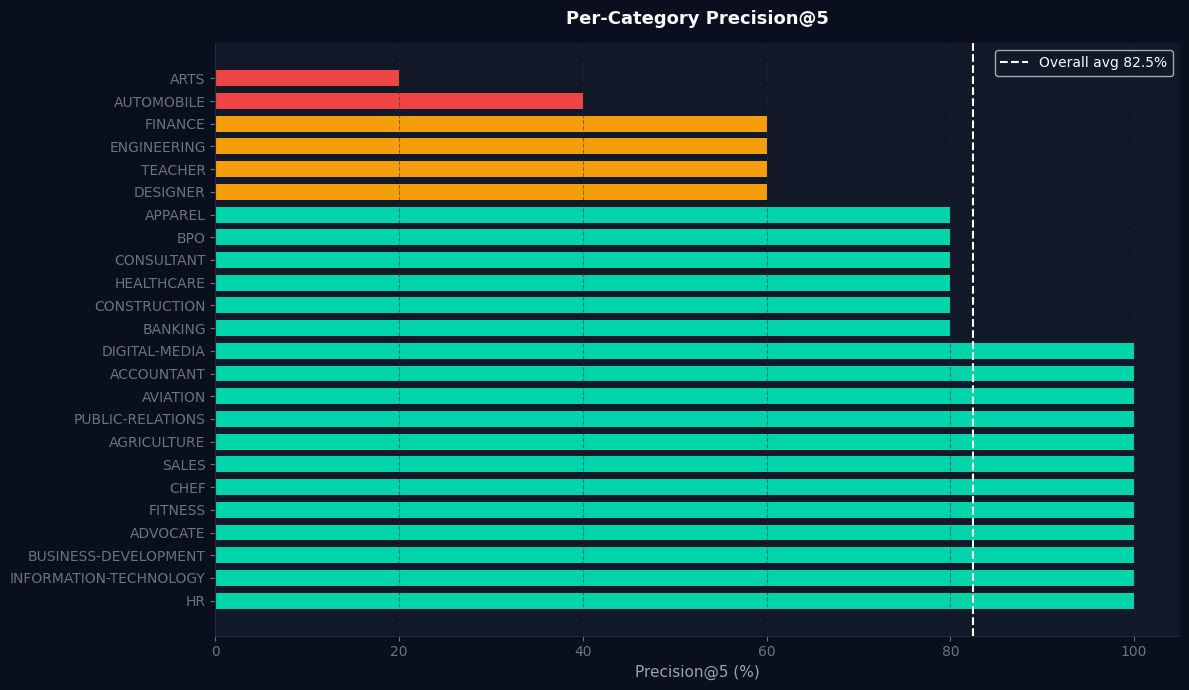

In [11]:
overall_p5 = p_at_5_df[f'P@{K} (%)'].mean()
print(f'=== Precision@{K} Results ===')
print(p_at_5_df.to_string(index=False))
print(f'\n>>> Overall Macro-Average P@{K}: {overall_p5:.1f}%')

# Bar chart
fig, ax = plt.subplots(figsize=(12, 7))

colors = [
    '#00D4AA' if v >= 80 else '#F59E0B' if v >= 60 else '#EF4444'
    for v in p_at_5_df[f'P@{K} (%)']
]

ax.barh(
    p_at_5_df['Category'],
    p_at_5_df[f'P@{K} (%)'],
    color=colors, height=0.7
)
ax.axvline(overall_p5, color='white', linewidth=1.5, linestyle='--',
           label=f'Overall avg {overall_p5:.1f}%')
ax.set_xlabel(f'Precision@{K} (%)', fontsize=11)
ax.set_title(f'Per-Category Precision@{K}', fontsize=13, fontweight='bold', color='#F9FAFB', pad=14)
ax.set_xlim(0, 105)
ax.legend(fontsize=10)
ax.grid(axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/precision_at_5.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 9 — Save Model Artifacts

Save the three artifacts the FastAPI backend needs at startup:
1. `resume_embeddings.pkl` — pre-computed NumPy matrix  
2. `resume_data.pkl`       — cleaned DataFrame  
3. `bert_model/`           — the sentence-transformer model directory

In [12]:
EMB_PATH   = os.path.join(SAVED_DIR, 'resume_embeddings.pkl')
DATA_PKL   = os.path.join(SAVED_DIR, 'resume_data.pkl')
MODEL_DIR  = os.path.join(SAVED_DIR, 'bert_model')

print('Saving artifacts…')

joblib.dump(embeddings, EMB_PATH, compress=3)
print(f'  ✓ Embeddings  → {EMB_PATH}')

joblib.dump(df[['Category', 'Resume_str']], DATA_PKL, compress=3)
print(f'  ✓ Resume data → {DATA_PKL}')

model.save(MODEL_DIR)
print(f'  ✓ BERT model  → {MODEL_DIR}')

print('\n✓ All artifacts saved successfully!')

Saving artifacts…
  ✓ Embeddings  → ../backend/models/saved\resume_embeddings.pkl
  ✓ Resume data → ../backend/models/saved\resume_data.pkl


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.01it/s]

  ✓ BERT model  → ../backend/models/saved\bert_model

✓ All artifacts saved successfully!


## Cell 10 — Confirm Saved Files and Print Sizes

Verify that all three artifacts exist and are non-empty before launching the backend.

In [13]:
def file_size(path: str) -> str:
    if os.path.isdir(path):
        total = sum(
            os.path.getsize(os.path.join(root, f))
            for root, _, files in os.walk(path)
            for f in files
        )
        return f'{total / (1024**2):.1f} MB (dir)'
    size = os.path.getsize(path)
    return f'{size / (1024**2):.2f} MB'


artifacts = [
    ('Embeddings matrix', EMB_PATH),
    ('Resume DataFrame',  DATA_PKL),
    ('BERT model dir',    MODEL_DIR),
]

print('=== Saved Artifacts ===')
print(f'{"Artifact":<25} {"Path":<55} {"Size"}')
print('-' * 90)

all_ok = True
for name, path in artifacts:
    exists = os.path.exists(path)
    status = file_size(path) if exists else 'MISSING ✗'
    if not exists:
        all_ok = False
    print(f'{name:<25} {path:<55} {status}')

print()
if all_ok:
    print('✓ All artifacts present. You can now start the backend:')
    print('  docker-compose up --build')
    print('  — or —')
    print('  cd ../backend && uvicorn main:app --reload')
else:
    print('✗ Some artifacts are missing — re-run cells 9 above.')

print(f'\nModel: {MODEL_DIR}')
print(f'Embeddings shape after reload: {joblib.load(EMB_PATH).shape}')
print(f'Resume count: {len(joblib.load(DATA_PKL)):,}')

=== Saved Artifacts ===
Artifact                  Path                                                    Size
------------------------------------------------------------------------------------------
Embeddings matrix         ../backend/models/saved\resume_embeddings.pkl           3.38 MB
Resume DataFrame          ../backend/models/saved\resume_data.pkl                 3.66 MB
BERT model dir            ../backend/models/saved\bert_model                      87.3 MB (dir)

✓ All artifacts present. You can now start the backend:
  docker-compose up --build
  — or —
  cd ../backend && uvicorn main:app --reload

Model: ../backend/models/saved\bert_model
Embeddings shape after reload: (2483, 384)
Resume count: 2,483
